# Étape 10 — Représentations et features des nœuds

Une **feature de nœud** est une information numérique ou catégorielle décrivant un nœud. Un
classifieur ne manipule pas directement un graphe ou un texte brut : il a besoin d'une représentation
vectorielle, c'est-à-dire d'une ligne de valeurs par CV ou Job.

Nous distinguons trois familles complémentaires :

- **structurelles** : position dans le graphe (degré, PageRank, composante) ;
- **communautaires** : groupe global du nœud et diversité des familles de skills d'un CV ;
- **sémantiques** : vecteur dense représentant le texte.

Deux versions sont construites avec la même méthode : graphe original observé et graphe enrichi.
Cela permettra plus tard d'étudier l'effet de l'enrichissement, tout en conservant l'original comme
évaluation principale la plus propre. Aucun classifieur, split de classification, scaling ou PCA
n'est réalisé dans ce notebook.

## 1. Imports, chemins et contrôles initiaux

Les chemins restent relatifs au projet. Nous chargeons les deux graphes comme des objets distincts
et vérifions leurs partitions. Une arête ajoutée doit toujours relier un CV à un Job. Les empreintes
SHA-256 des embeddings Step 7 sont mémorisées afin de prouver qu'ils ne sont pas écrasés.

In [1]:
from pathlib import Path
from collections import Counter, defaultdict
import hashlib, json, pickle, random, time
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sentence_transformers import SentenceTransformer
from IPython.display import display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data" / "processed"
RESULTS_DIR = ROOT / "results"
FIGURES_DIR = ROOT / "figures" / "step10"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
start_time = time.perf_counter()

def sha256(path):
    h = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""): h.update(chunk)
    return h.hexdigest()

step7_paths = [DATA_DIR / "resume_embeddings.npy", DATA_DIR / "job_embeddings.npy"]
step7_hashes_before = {p.name: sha256(p) for p in step7_paths}
with (DATA_DIR / "cv_job_graph.pkl").open("rb") as f: G_original = pickle.load(f)
with (DATA_DIR / "cv_job_graph_enriched.pkl").open("rb") as f: G_enriched = pickle.load(f)

assert (G_original.number_of_nodes(), G_original.number_of_edges()) == (12_500, 75_000)
assert (G_enriched.number_of_nodes(), G_enriched.number_of_edges()) == (12_500, 80_347)
assert set(G_original) == set(G_enriched)
assert G_original.number_of_edges() == 75_000
assert all(G_enriched.nodes[u]["node_type"] != G_enriched.nodes[v]["node_type"] for u,v in G_enriched.edges())
print("Graphes chargés :", G_original.number_of_edges(), "et", G_enriched.number_of_edges(), "arêtes.")

Graphes chargés : 75000 et 80347 arêtes.


## 2. Partitions et ordre déterministe

Le graphe est biparti : les voisins d'un CV sont des Jobs et inversement. Nous trions les IDs afin
que chaque CSV, mapping d'embeddings et tableau futur utilise exactement le même ordre, indépendamment
de l'ordre interne d'un dictionnaire Python.

In [2]:
resume_nodes = sorted(n for n,d in G_original.nodes(data=True) if d.get("node_type") == "CV")
job_nodes = sorted(n for n,d in G_original.nodes(data=True) if d.get("node_type") == "Job")
assert len(resume_nodes) == 10_000 and len(job_nodes) == 2_500
assert resume_nodes == sorted(n for n,d in G_enriched.nodes(data=True) if d.get("node_type") == "CV")
assert job_nodes == sorted(n for n,d in G_enriched.nodes(data=True) if d.get("node_type") == "Job")
print("CV / Jobs :", len(resume_nodes), len(job_nodes))

CV / Jobs : 10000 2500


## 3. Features structurelles communes

Le **degré** est le nombre de voisins : Jobs reliés pour un CV, CV reliés pour un Job. La centralité
générique `degree/(n-1)` serait artificielle ici, car un CV ne peut être relié qu'aux Jobs. Nous
utilisons donc : degré CV / 2 500 et degré Job / 10 000.

**PageRank** distribue une masse d'importance : un nœud est important s'il est relié à des nœuds
eux-mêmes importants. Nous appliquons exactement `alpha=0.85`, `tol=1e-8`, `max_iter=200` aux deux
graphes. `component_size` indique la taille du groupe connexe accessible et `is_isolate` signale un
nœud sans arête.

La même fonction évite qu'une différence original/enrichi provienne de paramètres différents.

In [3]:
PAGERANK_PARAMS = {"alpha": 0.85, "tol": 1e-8, "max_iter": 200}

def compute_structural_features(G, resume_nodes, job_nodes):
    resume_set, job_set = set(resume_nodes), set(job_nodes)
    pagerank = nx.pagerank(G, **PAGERANK_PARAMS)
    component_size = {}
    for component in nx.connected_components(G):
        size = len(component)
        component_size.update({node: size for node in component})
    rows = []
    for node in list(resume_nodes) + list(job_nodes):
        degree = G.degree(node)
        node_type = "CV" if node in resume_set else "Job"
        denominator = len(job_nodes) if node_type == "CV" else len(resume_nodes)
        rows.append({"node_id": node, "node_type": node_type, "degree": degree,
                     "bipartite_degree_centrality": degree / denominator,
                     "pagerank": pagerank[node], "is_isolate": int(degree == 0),
                     "component_size": component_size[node]})
    result = pd.DataFrame(rows)
    assert np.isclose(result.pagerank.sum(), 1.0)
    return result

struct_original = compute_structural_features(G_original, resume_nodes, job_nodes)
struct_enriched = compute_structural_features(G_enriched, resume_nodes, job_nodes)
display(struct_original.head())

,node_id,node_type,degree,bipartite_degree_centrality,pagerank,is_isolate,component_size
0,R_000000,CV,6,0.0024,0.000045,0,1628
1,R_000001,CV,9,0.0036,0.000063,0,1550
2,R_000002,CV,9,0.0036,0.000061,0,1628
3,R_000003,CV,6,0.0024,0.000044,0,1562
4,R_000004,CV,5,0.0020,0.000039,0,1562


## 4. Effet de l'enrichissement sur degré et PageRank

`degree_delta` mesure les nouvelles connexions de chaque nœud. `pagerank_delta` mesure la redistribution
de l'importance globale après ajout des arêtes. Nous comparons CV et Jobs séparément sans répéter
l'analyse structurelle complète de l'Étape 3.

In [4]:
delta = struct_original.merge(struct_enriched, on=["node_id","node_type"], suffixes=("_original","_enriched"))
delta["degree_delta"] = delta.degree_enriched - delta.degree_original
delta["pagerank_delta"] = delta.pagerank_enriched - delta.pagerank_original

comparison_rows = []
for version, frame in [("original", struct_original), ("enriched", struct_enriched)]:
    for node_type in ["CV", "Job"]:
        x = frame[frame.node_type == node_type]
        comparison_rows.append({"version": version, "node_type": node_type,
            "degree_mean": x.degree.mean(), "degree_median": x.degree.median(),
            "degree_min": x.degree.min(), "degree_max": x.degree.max(),
            "centrality_mean": x.bipartite_degree_centrality.mean(),
            "pagerank_mean": x.pagerank.mean(), "pagerank_median": x.pagerank.median(),
            "isolates": int(x.is_isolate.sum())})
structural_comparison = pd.DataFrame(comparison_rows)
display(structural_comparison)

delta_stats = {}
for node_type in ["CV", "Job"]:
    x = delta[delta.node_type == node_type]
    delta_stats[node_type] = {"fraction_degree_delta_zero": float((x.degree_delta==0).mean()),
                              "fraction_degree_delta_positive": float((x.degree_delta>0).mean()),
                              "mean_degree_delta": float(x.degree_delta.mean()),
                              "max_degree_delta": int(x.degree_delta.max()),
                              "mean_abs_pagerank_delta": float(x.pagerank_delta.abs().mean()),
                              "max_abs_pagerank_delta": float(x.pagerank_delta.abs().max())}
display(pd.DataFrame(delta_stats).T)

,version,node_type,degree_mean,degree_median,degree_min,degree_max,centrality_mean,pagerank_mean,pagerank_median,isolates
0,original,CV,7.5000,7.0,0,27,0.003000,0.000052,0.000050,29
1,original,Job,30.0000,30.0,30,30,0.003000,0.000190,0.000189,0
2,enriched,CV,8.0347,7.0,0,58,0.003214,0.000052,0.000048,29
3,enriched,Job,32.1388,32.0,30,38,0.003214,0.000190,0.000189,0


,fraction_degree_delta_zero,fraction_degree_delta_positive,mean_degree_delta,max_degree_delta,mean_abs_pagerank_delta,max_abs_pagerank_delta
CV,0.8400,0.1600,0.5347,41.0,0.000004,0.000189
Job,0.1072,0.8928,2.1388,8.0,0.000005,0.000027


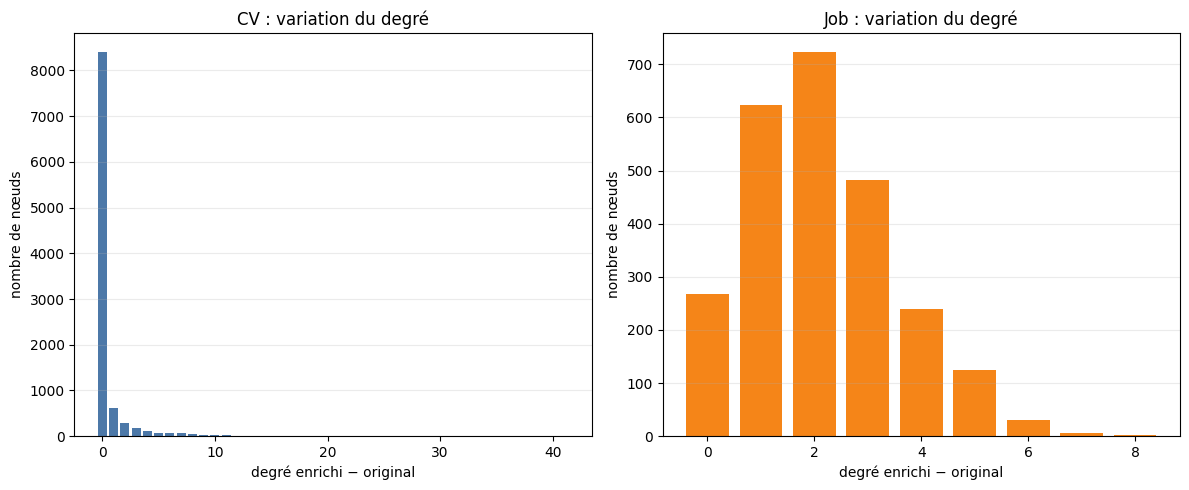

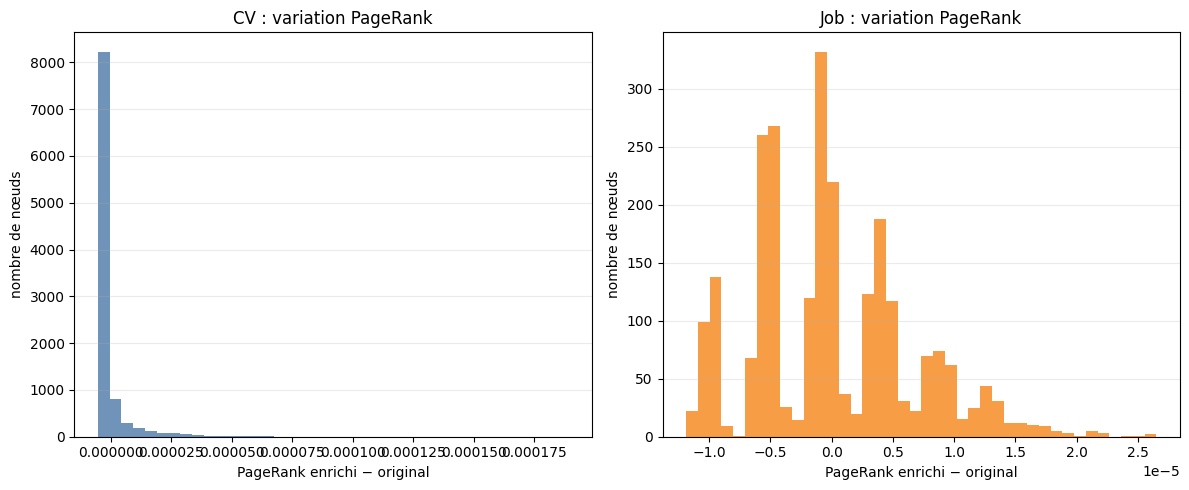

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, node_type, color in zip(axes, ["CV","Job"], ["#4C78A8","#F58518"]):
    x = delta.loc[delta.node_type == node_type, "degree_delta"]
    values, counts = np.unique(x, return_counts=True)
    ax.bar(values, counts, color=color); ax.set(title=f"{node_type} : variation du degré", xlabel="degré enrichi − original", ylabel="nombre de nœuds")
    ax.grid(axis="y", alpha=.25)
fig.tight_layout(); fig.savefig(FIGURES_DIR / "degree_change_original_vs_enriched.png", dpi=170, bbox_inches="tight"); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, node_type, color in zip(axes, ["CV","Job"], ["#4C78A8","#F58518"]):
    x = delta.loc[delta.node_type == node_type, "pagerank_delta"]
    ax.hist(x, bins=40, color=color, alpha=.8); ax.set(title=f"{node_type} : variation PageRank", xlabel="PageRank enrichi − original", ylabel="nombre de nœuds")
    ax.grid(axis="y", alpha=.25)
fig.tight_layout(); fig.savefig(FIGURES_DIR / "pagerank_change_original_vs_enriched.png", dpi=170, bbox_inches="tight"); plt.show()

## 5. Communautés originales validées

Une communauté regroupe des nœuds plus connectés entre eux que prévu par un modèle de référence.
`community_global` est une **catégorie**, pas une quantité : le numéro 4 n'est pas « supérieur » au
numéro 2. Nous réutilisons le fichier validé de l'Étape 4 et calculons seulement la taille de chaque
communauté. Aucun recalcul arbitraire n'est effectué pour l'original.

In [6]:
original_communities = pd.read_csv(RESULTS_DIR / "step4_global_communities.csv", dtype={"node_id": str})
original_community_summary = json.loads((RESULTS_DIR / "step4_community_summary.json").read_text(encoding="utf-8"))
assert len(original_communities) == 12_500 and original_communities.node_id.is_unique
assert set(original_communities.node_id) == set(G_original.nodes())
original_communities = original_communities[["node_id","community_global"]].rename(columns={"community_global":"community_global_original"})
original_sizes = original_communities.community_global_original.value_counts()
original_communities["community_size_original"] = original_communities.community_global_original.map(original_sizes)
print("Communautés originales :", original_sizes.size, "modularité :", original_community_summary["modularity_networkx"])

Communautés originales : 37 modularité : 0.8724577777777778


## 6. Communautés du graphe enrichi — même protocole que Step 4

De nouvelles arêtes peuvent fusionner ou réorganiser des groupes. Pour rester comparable, nous
réutilisons **exactement** la propagation asynchrone de labels de Step 4 : label unique initial,
ordre mélangé à chaque itération, label voisin majoritaire et tirage reproductible en cas d'égalité.
Nous testons les mêmes seeds `[0,1,2,3,4]`, `max_iter=100`, puis choisissons la modularité standard
maximale. Les isolés conservent leur label.

La modularité compare les arêtes internes observées à un modèle aléatoire de mêmes degrés. Comme à
Step 4, sa référence est standard et non spécifiquement bipartite : cette limite reste inchangée.

In [7]:
def label_propagation_manual(G, seed=42, max_iter=100):
    rng = random.Random(seed)
    nodes = list(G.nodes())
    labels = {node: index for index, node in enumerate(nodes)}
    for iteration in range(1, max_iter + 1):
        rng.shuffle(nodes); n_changes = 0
        for node in nodes:
            neighbors = list(G.neighbors(node))
            if not neighbors: continue
            counts = Counter(labels[n] for n in neighbors)
            max_count = max(counts.values())
            choices = [label for label,count in counts.items() if count == max_count]
            new_label = rng.choice(choices)
            if new_label != labels[node]: labels[node] = new_label; n_changes += 1
        if n_changes == 0: return labels, iteration, True
    return labels, max_iter, False

def labels_to_communities(labels):
    groups = defaultdict(set)
    for node,label in labels.items(): groups[label].add(node)
    return list(groups.values())

SEEDS, MAX_ITER = [0,1,2,3,4], 100
run_rows, partitions = [], {}
for seed in SEEDS:
    labels, iterations, converged = label_propagation_manual(G_enriched, seed, MAX_ITER)
    communities = labels_to_communities(labels)
    modularity = nx.algorithms.community.modularity(G_enriched, communities)
    sizes = [len(c) for c in communities]
    run_rows.append({"seed": seed, "iterations": iterations, "converged": converged,
                     "n_communities": len(communities), "modularity": modularity,
                     "smallest_community": min(sizes), "largest_community": max(sizes)})
    partitions[seed] = communities
enriched_runs = pd.DataFrame(run_rows)
best_row = enriched_runs.loc[enriched_runs.modularity.idxmax()]
best_seed = int(best_row.seed)
best_communities = sorted(partitions[best_seed], key=lambda c: (-len(c), min(c)))
community_enriched_of = {node:i for i,c in enumerate(best_communities) for node in c}
enriched_sizes = pd.Series(community_enriched_of).value_counts().sort_index()
enriched_communities = pd.DataFrame({"node_id": list(G_enriched.nodes())})
enriched_communities["node_type"] = enriched_communities.node_id.map(nx.get_node_attributes(G_enriched,"node_type"))
enriched_communities["community_global_enriched"] = enriched_communities.node_id.map(community_enriched_of)
enriched_communities["community_size_enriched"] = enriched_communities.community_global_enriched.map(enriched_sizes)
enriched_communities = enriched_communities.sort_values("node_id").reset_index(drop=True)
enriched_communities.to_csv(RESULTS_DIR / "step10_enriched_global_communities.csv", index=False)
enriched_community_summary = {"method":"manual asynchronous label propagation", "seeds_tested":SEEDS,
    "max_iter":MAX_ITER, "selected_seed":best_seed, "selection_reason":"highest standard modularity among tested seeds",
    "selected_iterations":int(best_row.iterations), "selected_converged":bool(best_row.converged),
    "n_communities":len(best_communities), "modularity":float(best_row.modularity),
    "community_size_min":int(enriched_sizes.min()), "community_size_median":float(enriched_sizes.median()),
    "community_size_mean":float(enriched_sizes.mean()), "community_size_max":int(enriched_sizes.max()),
    "runs":run_rows, "modularity_limit":"standard modularity on a bipartite graph"}
(RESULTS_DIR / "step10_enriched_community_summary.json").write_text(json.dumps(enriched_community_summary,indent=2,ensure_ascii=False),encoding="utf-8")
display(enriched_runs)
print("Seed enrichi retenu :", best_seed)

,seed,iterations,converged,n_communities,modularity,smallest_community,largest_community
0,0,11,True,37,0.872558,1,1628
1,1,9,True,37,0.872558,1,1628
2,2,10,True,37,0.872556,1,1628
3,3,24,True,37,0.872558,1,1628
4,4,24,True,37,0.872558,1,1628


Seed enrichi retenu : 1


## 7. Stabilité des partitions : ARI et NMI

Les numéros de communautés sont arbitraires : comparer directement `ID_original == ID_enriched`
serait faux si deux partitions identiques utilisent d'autres numéros. L'**Adjusted Rand Index**
compare les paires regroupées ou séparées en corrigeant le hasard. La **Normalized Mutual
Information** mesure l'information partagée entre partitions. Les deux valent 1 pour un regroupement
identique, indépendamment des noms de groupes. Cette comparaison est descriptive, pas une performance
de classification.

In [8]:
partition_compare = original_communities.merge(enriched_communities[["node_id","community_global_enriched"]], on="node_id", validate="one_to_one")
community_ari = adjusted_rand_score(partition_compare.community_global_original, partition_compare.community_global_enriched)
community_nmi = normalized_mutual_info_score(partition_compare.community_global_original, partition_compare.community_global_enriched)
print("ARI :", community_ari, "NMI :", community_nmi)

ARI : 0.9996356991010776 NMI : 0.9993636701407612


## 8. Features internes des skills des CV

Ces features projettent les communautés du graphe de compétences sur chaque CV : nombre de skills,
nombre de familles, famille dominante, part dominante et entropie de diversité. Elles ne dépendent
pas des arêtes CV–Job, donc restent strictement identiques entre original et enrichi.

`dominant_skill_community` est catégorielle. Nous ne construisons pas encore le label
spécialisé/polyvalent : le faire ici transformerait une feature en cible avant définition du protocole
de classification.

In [9]:
skill_features = pd.read_csv(RESULTS_DIR / "step5_cv_internal_community_features.csv", dtype={"resume_id":str})
skill_columns = ["n_skills","n_skill_communities","dominant_skill_community",
                 "dominant_skill_community_count","dominant_skill_community_share",
                 "skill_community_entropy","skill_community_entropy_normalized"]
assert len(skill_features) == 10_000 and skill_features.resume_id.is_unique
assert set(skill_features.resume_id) == set(resume_nodes)
display(skill_features.head())

,resume_id,n_skills,n_skill_communities,dominant_skill_community,dominant_skill_community_count,dominant_skill_community_share,skill_community_entropy,skill_community_entropy_normalized
0,R_000000,7,1,3,7,1.000000,-0.000000,0.000000
1,R_000001,5,1,0,5,1.000000,-0.000000,0.000000
2,R_000002,6,1,3,6,1.000000,-0.000000,0.000000
3,R_000003,6,2,6,5,0.833333,0.450561,0.650022
4,R_000004,5,1,6,5,1.000000,-0.000000,0.000000


## 9. Audit de fuite des embeddings Step 7

Les embeddings Step 7 restent valides pour la prédiction de liens, mais leurs textes contiennent
directement `seniority` côté CV/Job et `industry` côté Job. Les utiliser pour prédire ces mêmes
cibles donnerait pratiquement la réponse au modèle : c'est une **fuite de cible**.

Nous préservons ces fichiers et les déclarons `purpose=link_prediction` et
`unsafe_for_direct_target_classification=true` dans le manifest. Nous créons de nouveaux textes :

- CV seniority-safe : rôle, années d'expérience, industrie, éducation, skills, résumé, expériences,
  mais jamais le champ direct seniority ;
- Job générique : titre, skills, description, responsabilités, exigences, sans champs directs
  seniority ni industry.

Nuance : les embeddings CV ne sont pas automatiquement sûrs pour une future cible
spécialisé/polyvalent si cette cible est construite à partir des skills qu'ils contiennent.

In [10]:
def clean(value):
    if value is None: return ""
    if isinstance(value, (list,tuple)): return "; ".join(map(str,value))
    return str(value)

def build_resume_safe_text(node):
    d = G_original.nodes[node]
    fields = [("Role",d.get("role")), ("Years of experience",d.get("years_experience")),
              ("Industry",d.get("industry")), ("Education",d.get("education")),
              ("Skills",d.get("skills")), ("Summary",d.get("summary")),
              ("Experience",d.get("experience_bullets"))]
    return "\n".join(f"{label}: {clean(value)}" for label,value in fields if clean(value))

def build_job_safe_text(node):
    d = G_original.nodes[node]
    fields = [("Job title",d.get("job_title")), ("Must-have skills",d.get("must_have_skills")),
              ("Nice-to-have skills",d.get("nice_to_have_skills")), ("Description",d.get("description")),
              ("Responsibilities",d.get("responsibilities")), ("Requirements",d.get("requirements"))]
    return "\n".join(f"{label}: {clean(value)}" for label,value in fields if clean(value))

resume_safe_texts = [build_resume_safe_text(n) for n in resume_nodes]
job_safe_texts = [build_job_safe_text(n) for n in job_nodes]
print("Exemples CV safe :"); display(pd.DataFrame({"resume_id":resume_nodes[:3],"text":resume_safe_texts[:3]}))
print("Exemples Job safe :"); display(pd.DataFrame({"job_id":job_nodes[:3],"text":job_safe_texts[:3]}))

Exemples CV safe :


,resume_id,text
0,R_000000,Role: Software Engineer\nYears of experience: ...
1,R_000001,Role: Marketing Manager\nYears of experience: ...
2,R_000002,Role: Full Stack Engineer\nYears of experience...


Exemples Job safe :


,job_id,text
0,J_000000,Job title: Project Manager\nMust-have skills: ...
1,J_000001,Job title: Customer Success Associate\nMust-ha...
2,J_000002,Job title: FP&A Analyst\nMust-have skills: Var...


## 10. Embeddings classification-safe

Un embedding transforme un texte en vecteur numérique : des contenus proches occupent des régions
proches du même espace. Nous utilisons le même modèle `all-MiniLM-L6-v2` que Step 7 pour obtenir 384
dimensions comparables, mais avec les textes sans cible directe. `normalize_embeddings=True` impose
une norme L2 égale à 1.

Ces matrices sont sauvegardées séparément. Aucune PCA ne réduit les dimensions et aucun modèle n'est
fine-tuné ou entraîné.

In [11]:
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
model = SentenceTransformer(MODEL_NAME)
encode_start = time.perf_counter()
resume_safe_embeddings = model.encode(resume_safe_texts, batch_size=64, show_progress_bar=True,
                                      normalize_embeddings=True, convert_to_numpy=True)
resume_encode_seconds = time.perf_counter() - encode_start
job_start = time.perf_counter()
job_safe_embeddings = model.encode(job_safe_texts, batch_size=64, show_progress_bar=True,
                                   normalize_embeddings=True, convert_to_numpy=True)
job_encode_seconds = time.perf_counter() - job_start

np.save(DATA_DIR / "resume_classification_embeddings.npy", resume_safe_embeddings)
np.save(DATA_DIR / "job_classification_embeddings.npy", job_safe_embeddings)
pd.DataFrame({"resume_id":resume_nodes,"embedding_row":np.arange(len(resume_nodes))}).to_csv(DATA_DIR / "resume_classification_embedding_ids.csv",index=False)
pd.DataFrame({"job_id":job_nodes,"embedding_row":np.arange(len(job_nodes))}).to_csv(DATA_DIR / "job_classification_embedding_ids.csv",index=False)
print(resume_safe_embeddings.shape, job_safe_embeddings.shape, resume_safe_embeddings.dtype)

'(MaxRetryError("HTTPSConnectionPool(host='huggingface.co', port=443): Max retries exceeded with url: /sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json (Caused by NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x0000024C3AEF7C20>: Failed to establish a new connection: [WinError 10013] Une tentative d’accès à un socket de manière interdite par ses autorisations d’accès a été tentée'))"), '(Request ID: 88a15a07-7585-4385-8599-69b2a8028fe7)')' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/./modules.json


Retrying in 1s [Retry 1/5].


'(MaxRetryError("HTTPSConnectionPool(host='huggingface.co', port=443): Max retries exceeded with url: /sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json (Caused by NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x0000024C3C9D0D40>: Failed to establish a new connection: [WinError 10013] Une tentative d’accès à un socket de manière interdite par ses autorisations d’accès a été tentée'))"), '(Request ID: 454d20f3-9f42-46e3-b740-2a58b6016351)')' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/./modules.json


Retrying in 2s [Retry 2/5].


'(MaxRetryError("HTTPSConnectionPool(host='huggingface.co', port=443): Max retries exceeded with url: /sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json (Caused by NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x0000024C3C67A720>: Failed to establish a new connection: [WinError 10013] Une tentative d’accès à un socket de manière interdite par ses autorisations d’accès a été tentée'))"), '(Request ID: 091b5fd9-b9af-474c-8c9d-924db0273d4a)')' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/./modules.json


...

Retrying in 8s [Retry 5/5].


'(MaxRetryError("HTTPSConnectionPool(host='huggingface.co', port=443): Max retries exceeded with url: /sentence-transformers/all-MiniLM-L6-v2/resolve/main/1_Pooling/config.json (Caused by NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x0000024C3CBAB3E0>: Failed to establish a new connection: [WinError 10013] Une tentative d’accès à un socket de manière interdite par ses autorisations d’accès a été tentée'))"), '(Request ID: 20b47449-9a9a-48f5-bba2-5ae85672d392)')' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/1_Pooling/config.json


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Batches:   0%|          | 0/40 [00:00<?, ?it/s]

(10000, 384) (2500, 384) float32


## 11. Risque indirect propre au graphe enrichi

L'enrichissement Step 9 utilise les embeddings de link prediction qui incluaient seniority et
industry. Les arêtes prédites, puis le degré, PageRank et les communautés de `G_enriched`, peuvent
donc transporter indirectement de l'information liée aux futures cibles.

Conséquence méthodologique : `G_original` sera l'évaluation principale la plus propre. La version
enrichie restera une analyse expérimentale, et un gain ne prouvera pas une amélioration indépendante
des labels. Le résumé conserve explicitement
`enriched_graph_indirect_target_leakage_risk=true`.

## 12. Tables de predictors et fichiers de targets séparés

Les tables CSV contiennent uniquement les predictors tabulaires. Les embeddings restent en NPY pour
éviter 384 colonnes peu lisibles. Les targets sont écrites dans deux fichiers distincts afin qu'une
colonne cible ne soit jamais sélectionnée implicitement comme feature.

In [12]:
def node_feature_table(struct, communities, nodes, id_name, community_suffix):
    x = struct[struct.node_id.isin(nodes)].copy().drop(columns="node_type")
    x = x.merge(communities, on="node_id", validate="one_to_one")
    rename = {"node_id":id_name, f"community_global_{community_suffix}":"community_global",
              f"community_size_{community_suffix}":"community_size"}
    return x.rename(columns=rename).sort_values(id_name).reset_index(drop=True)

resume_original = node_feature_table(struct_original, original_communities, resume_nodes, "resume_id", "original")
resume_enriched = node_feature_table(struct_enriched, enriched_communities[["node_id","community_global_enriched","community_size_enriched"]], resume_nodes, "resume_id", "enriched")
resume_original = resume_original.merge(skill_features, on="resume_id", validate="one_to_one")
resume_enriched = resume_enriched.merge(skill_features, on="resume_id", validate="one_to_one")
job_original = node_feature_table(struct_original, original_communities, job_nodes, "job_id", "original")
job_enriched = node_feature_table(struct_enriched, enriched_communities[["node_id","community_global_enriched","community_size_enriched"]], job_nodes, "job_id", "enriched")

resume_original.to_csv(RESULTS_DIR / "step10_resume_features_original.csv", index=False)
resume_enriched.to_csv(RESULTS_DIR / "step10_resume_features_enriched.csv", index=False)
job_original.to_csv(RESULTS_DIR / "step10_job_features_original.csv", index=False)
job_enriched.to_csv(RESULTS_DIR / "step10_job_features_enriched.csv", index=False)

resume_targets = pd.DataFrame({"resume_id":resume_nodes,"seniority":[G_original.nodes[n].get("seniority") for n in resume_nodes]})
job_targets = pd.DataFrame({"job_id":job_nodes,"seniority":[G_original.nodes[n].get("seniority") for n in job_nodes],
                            "industry":[G_original.nodes[n].get("industry") for n in job_nodes]})
resume_targets.to_csv(RESULTS_DIR / "step10_resume_targets.csv",index=False)
job_targets.to_csv(RESULTS_DIR / "step10_job_targets.csv",index=False)
print("Predictors CV/Job :", resume_original.shape, job_original.shape)

Predictors CV/Job : (10000, 15) (2500, 8)


## 13. Manifest des features

Le manifest est un contrat pour Step 11 : type, source, version du graphe, type de nœud et sûreté
par cible. Les communautés et familles dominantes sont catégorielles. Les embeddings Step 7 y sont
explicitement distingués des nouveaux embeddings safe.

In [13]:
manifest = {"features":[], "embedding_artifacts":[]}
structural_cols = ["degree","bipartite_degree_centrality","pagerank","is_isolate","component_size"]
for node_type in ["CV","Job"]:
    for version in ["original","enriched"]:
        risk = version == "enriched"
        for name in structural_cols:
            manifest["features"].append({"name":name,"type":"numeric","source":"graph","graph_version":version,
                "node_type":node_type,"safe_for_cv_seniority":not risk,"safe_for_job_seniority":not risk,
                "safe_for_job_industry":not risk,"remarks":"enriched graph carries indirect target leakage risk" if risk else "observed graph"})
        for name in ["community_global","community_size"]:
            manifest["features"].append({"name":name,"type":"categorical" if name=="community_global" else "numeric",
                "source":"graph","graph_version":version,"node_type":node_type,
                "safe_for_cv_seniority":not risk,"safe_for_job_seniority":not risk,"safe_for_job_industry":not risk,
                "remarks":"community ID is categorical; enriched risk applies" if risk else "community ID is categorical"})
for name in skill_columns:
    manifest["features"].append({"name":name,"type":"categorical" if name=="dominant_skill_community" else "numeric",
        "source":"skill_graph","graph_version":"invariant","node_type":"CV","safe_for_cv_seniority":True,
        "safe_for_job_seniority":False,"safe_for_job_industry":False,
        "remarks":"not automatically safe for a specialized/generalist target derived from skills"})
manifest["embedding_artifacts"] = [
    {"name":"resume_embeddings.npy","type":"embedding","source":"semantic","graph_version":"invariant","node_type":"CV",
     "purpose":"link_prediction","unsafe_for_direct_target_classification":True,"safe_for_cv_seniority":False,
     "safe_for_job_seniority":False,"safe_for_job_industry":False,"remarks":"Step 7 text directly included seniority"},
    {"name":"job_embeddings.npy","type":"embedding","source":"semantic","graph_version":"invariant","node_type":"Job",
     "purpose":"link_prediction","unsafe_for_direct_target_classification":True,"safe_for_cv_seniority":False,
     "safe_for_job_seniority":False,"safe_for_job_industry":False,"remarks":"Step 7 text directly included seniority and industry"},
    {"name":"resume_classification_embeddings.npy","type":"embedding","source":"semantic","graph_version":"invariant","node_type":"CV",
     "purpose":"classification","unsafe_for_direct_target_classification":False,"safe_for_cv_seniority":True,
     "safe_for_job_seniority":False,"safe_for_job_industry":False,"remarks":"not automatically safe for skill-derived specialized/generalist"},
    {"name":"job_classification_embeddings.npy","type":"embedding","source":"semantic","graph_version":"invariant","node_type":"Job",
     "purpose":"classification","unsafe_for_direct_target_classification":False,"safe_for_cv_seniority":False,
     "safe_for_job_seniority":True,"safe_for_job_industry":True,"remarks":"direct seniority and industry fields excluded"},
]
(RESULTS_DIR / "step10_feature_manifest.json").write_text(json.dumps(manifest,indent=2,ensure_ascii=False),encoding="utf-8")

13597

## 14. Pourquoi aucun preprocessing ML n'est ajusté ici

`StandardScaler.fit`, `PCA.fit`, `OneHotEncoder.fit`, sélection supervisée et SMOTE apprennent des
paramètres à partir des données. Les ajuster avant le split de classification exposerait indirectement
le futur jeu test au pipeline. Ils seront placés dans un pipeline ajusté **uniquement sur le train**
à Step 11. Les embeddings restent donc bruts en 384 dimensions et aucun label spécialisé/polyvalent
n'est défini maintenant.

## 15. Assertions de qualité et absence de fuite directe

Ces contrôles vérifient dimensions, ordre, finitude, présence des communautés, invariance des
features de skills, textes sans préfixe cible, préservation des fichiers Step 7 et absence de toute
étape d'apprentissage. Un échec arrête le notebook.

In [14]:
numeric_resume = [c for c in resume_original.columns if c not in ["resume_id","community_global","dominant_skill_community"]]
numeric_job = [c for c in job_original.columns if c not in ["job_id","community_global"]]
assert len(resume_original)==len(resume_enriched)==10_000
assert len(job_original)==len(job_enriched)==2_500
assert resume_original.resume_id.tolist()==resume_enriched.resume_id.tolist()==resume_nodes
assert job_original.job_id.tolist()==job_enriched.job_id.tolist()==job_nodes
assert resume_original.resume_id.is_unique and job_original.job_id.is_unique
for frame, cols in [(resume_original,numeric_resume),(resume_enriched,numeric_resume),(job_original,numeric_job),(job_enriched,numeric_job)]:
    assert np.isfinite(frame[cols].to_numpy(dtype=float)).all()
    assert frame.community_global.notna().all() and frame.community_size.notna().all()
pd.testing.assert_frame_equal(resume_original[["resume_id"]+skill_columns], resume_enriched[["resume_id"]+skill_columns])
assert resume_safe_embeddings.shape==(10_000,384) and job_safe_embeddings.shape==(2_500,384)
assert np.isfinite(resume_safe_embeddings).all() and np.isfinite(job_safe_embeddings).all()
assert np.allclose(np.linalg.norm(resume_safe_embeddings,axis=1),1,atol=1e-4)
assert np.allclose(np.linalg.norm(job_safe_embeddings,axis=1),1,atol=1e-4)
assert all("Seniority:" not in text for text in resume_safe_texts)
assert all("Seniority:" not in text and "Industry:" not in text for text in job_safe_texts)
assert step7_hashes_before == {p.name:sha256(p) for p in step7_paths}
assert set(original_communities.node_id)==set(enriched_communities.node_id)==set(G_original.nodes())
assert not ({"seniority","industry"} & set(resume_original.columns))
assert not ({"seniority","industry"} & set(job_original.columns))
print("Toutes les assertions sont passées. Aucun scaler, PCA ou classifieur n'a été ajusté.")

Toutes les assertions sont passées. Aucun scaler, PCA ou classifieur n'a été ajusté.


## 16. Résumé reproductible

Le JSON rassemble les versions des graphes, communautés, deltas, champs sémantiques autorisés et
exclus, ainsi que les drapeaux de fuite et de preprocessing. Il prépare Step 11 sans la commencer.

In [15]:
summary = {"n_resumes":10_000,"n_jobs":2_500,"original_edges":75_000,"enriched_edges":80_347,
 "structural_features":["degree","bipartite_degree_centrality","pagerank","is_isolate","component_size"],
 "resume_internal_features":skill_columns,
 "n_tabular_resume_predictor_features":int(len(resume_original.columns)-1),
 "n_tabular_job_predictor_features":int(len(job_original.columns)-1),
 "original_community_count":int(original_sizes.size),"enriched_community_count":len(best_communities),
 "original_modularity":float(original_community_summary["modularity_networkx"]),"enriched_modularity":float(best_row.modularity),
 "enriched_community_selected_seed":best_seed,"enriched_community_runs":run_rows,
 "community_ARI":float(community_ari),"community_NMI":float(community_nmi),
 "structural_comparison":structural_comparison.to_dict(orient="records"),"delta_statistics":delta_stats,
 "resume_safe_embedding_model":MODEL_NAME,"job_safe_embedding_model":MODEL_NAME,"embedding_dimension":384,
 "resume_safe_text_fields":["role","years_experience","industry","education","skills","summary","experience_bullets"],
 "resume_excluded_target_fields":["seniority"],
 "job_safe_text_fields":["job_title","must_have_skills","nice_to_have_skills","description","responsibilities","requirements"],
 "job_excluded_target_fields":["seniority","industry"],
 "resume_embedding_seconds":resume_encode_seconds,"job_embedding_seconds":job_encode_seconds,
 "step7_embeddings_preserved":True,"step7_embedding_purpose":"link_prediction",
 "step7_embeddings_unsafe_for_direct_target_classification":True,
 "enriched_graph_indirect_target_leakage_risk":True,
 "specialized_generalist_label_created":False,"no_scaler_fitted":True,"no_pca_fitted":True,
 "classification_started":False,"all_assertions_passed":True,"runtime_seconds":float(time.perf_counter()-start_time)}
(RESULTS_DIR / "step10_node_features_summary.json").write_text(json.dumps(summary,indent=2,ensure_ascii=False),encoding="utf-8")
print("Résumé sauvegardé. Temps total :",round(summary["runtime_seconds"],2),"s")

Résumé sauvegardé. Temps total : 417.23 s


## Interprétation et conclusion

- L'enrichissement ajoute 5 347 arêtes. Le degré moyen des CV passe de `7,5` à `8,0347` et celui
  des Jobs de `30` à `32,1388`. Seuls `16 %` des CV gagnent une arête, contre `89,28 %` des Jobs.
  Le delta maximal vaut `41` pour un CV et `8` pour un Job ; les `29` CV isolés restent isolés.
- PageRank change globalement peu : le delta absolu moyen vaut `3,87e-6` côté CV et `5,18e-6`
  côté Job. Sa moyenne par partition ne change pas, car la masse PageRank totale reste normalisée,
  mais sa répartition individuelle évolue.
- Les deux graphes produisent `37` communautés. La modularité standard passe légèrement de
  `0,872458` à `0,872558`. ARI=`0,999636` et NMI=`0,999364` indiquent une partition presque
  identique malgré les nouveaux liens ; les numéros de communauté n'ont pas été comparés directement.
- Chaque CV dispose de `14` predictors tabulaires : 5 structurels, 2 communautaires globales et
  7 liés aux communautés internes de skills. Chaque Job en possède `7` : 5 structurels et 2
  communautaires. À cela s'ajoute séparément un embedding sémantique de `384` dimensions.
- Les embeddings Step 7 sont préservés pour la link prediction, mais ne sont pas utilisés directement
  pour les classifications dont les cibles apparaissaient dans leurs textes. Les nouveaux textes CV
  excluent `seniority`; les textes Job excluent `seniority` et `industry`.
- PCA, scaling, encodage catégoriel et classifieur sont reportés à Step 11 afin que leur ajustement
  soit effectué uniquement sur le futur train et ne voie jamais le test. Aucun label
  spécialisé/polyvalent n'a été créé.
- Enfin, les features de `G_enriched` présentent un risque indirect : ses arêtes ont été sélectionnées
  avec des embeddings Step 7 contenant seniority/industry. `G_original` restera donc l'évaluation
  principale la plus propre ; l'enrichi sera une analyse expérimentale à interpréter prudemment.